In [1]:
%load_ext autoreload
%autoreload 2

import os
import torchio as tio

# pra usar cpu, descomentar linha abaixo
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import math
import nibabel as nib

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger, EarlyStopping
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers, models, Input, Model

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
import gc
import seaborn as sns

from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from PIL import Image
import tempfile
import random

#import wandb

2025-12-22 14:19:20.987994: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-22 14:19:22.076266: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-22 14:19:22.359762: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-22 14:19:24.622092: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import sys
import os

# Obtém o caminho absoluto da pasta onde o notebook está
current_dir = os.getcwd()

# Obtém o caminho da pasta "pai" (um nível acima)
parent_dir = os.path.dirname(current_dir)

# Adiciona o diretório pai ao caminho de busca do Python
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# --- Agora os imports funcionarão ---
import utils.processamento_dados as proc_dados
import utils.metricas_e_visualizacao as met_vil

In [3]:
from tensorflow.keras import mixed_precision

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Evita uso excessivo de memória
        print("GPU habilitada com sucesso!")
        print("Memory Growth habilitado para a GPU")
    except RuntimeError as e:
        print(e)

mixed_precision.set_global_policy("mixed_float16")

tf.get_logger().setLevel('ERROR')

GPU habilitada com sucesso!
Memory Growth habilitado para a GPU


I0000 00:00:1766424026.456142  319527 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1766424026.461578  319527 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1766424026.461618  319527 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.


In [4]:
# FUNÇÕES

def create_model_3d(input_shape, n_classes):
    inputs = Input(shape=input_shape)  # (D, H, W, C)

    # Camada 1
    x = layers.Conv3D(4, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 2
    x = layers.Conv3D(8, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 3
    x = layers.Conv3D(16, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)
    
    # Flatten e densas
    x = layers.Flatten()(x)

    x = layers.Dense(16, kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model

In [5]:
# Definindo caminhos
dir_base = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn"

# train_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/train'
# val_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/validation'
# test_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/test'

fine_tunning_train_dir = f'{dir_base}/ADNI/ADNI_3_4_NORMALIZED/train'
fine_tunning_val_dir = f'{dir_base}/ADNI/ADNI_3_4_NORMALIZED/validation'
fine_tunning_test_dir = f'{dir_base}/ADNI/ADNI_3_4_NORMALIZED/test'

# oasis_train = f'{dir_base}/OASIS/OASIS_1_FSL_NORMALIZED/train'
# oasis_validation = f'{dir_base}/OASIS/OASIS_1_FSL_NORMALIZED/validation'

results_dir_base = f'{dir_base}/ADNI/ADNI_NORMALIZED/results/ruidos_pre_treino_fixo'
os.makedirs(results_dir_base, exist_ok=True)

transformations = ['noise']

# Nome das classes
adni_class_names = ['cn', 'ad']
oasis_class_names = ['0.0', '1.0']

n_adni_classes = len(adni_class_names)
n_oasis_classes = len(oasis_class_names)

fine_tunning_class_names = adni_class_names
n_fine_tunning_class_names = n_adni_classes

pretrained_model_path = f"{dir_base}/ADNI/ADNI_NORMALIZED/modelo_pretrained.keras"

# CARREGA O MODELO DA FASE 1
if not os.path.exists(pretrained_model_path):
    raise FileNotFoundError(f"Modelo pré-treinado não encontrado em {pretrained_model_path}. Rode a Fase 1 primeiro.")

print(f"Carregando pesos de: {pretrained_model_path}")
base_model = load_model(pretrained_model_path)

Carregando pesos de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/modelo_pretrained.keras


I0000 00:00:1766424039.365005  319527 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1766424039.365073  319527 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1766424039.365093  319527 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1766424039.698384  319527 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1766424039.698439  319527 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-12-22

# Transfer learning

In [6]:
train_images_fine_tunning, train_labels_fine_tunning, train_paths_fine_tunning, class_labels_fine_tunning = proc_dados.load_nifti_data_balanced_full_augment(
    fine_tunning_train_dir, 
    fine_tunning_class_names, 
    augment_originals=True
)

print(f"N treino: {len(train_images_fine_tunning)}")

val_images_fine_tunning, val_labels_fine_tunning, val_paths_fine_tunning, _ = proc_dados.load_nifti_data_balanced_full_augment(
    fine_tunning_val_dir, 
    fine_tunning_class_names,
    augment_originals=False
)

print(f"N validation: {len(val_paths_fine_tunning)}")

Passo 1: Mapeamento e Balanceamento...
-> Alvo de balanceamento: 611 imagens por classe.
   Gerando 523 cópias sintéticas para 'ad'...
Alocando memória para 1222 volumes (156, 195, 160)...
Passo 3: Carregando e aplicando transformações...
Progresso: 50/1222
Progresso: 100/1222
Progresso: 150/1222
Progresso: 200/1222
Progresso: 250/1222
Progresso: 300/1222
Progresso: 350/1222
Progresso: 400/1222
Progresso: 450/1222
Progresso: 500/1222
Progresso: 550/1222
Progresso: 600/1222
Progresso: 650/1222
Progresso: 700/1222
Progresso: 750/1222
Progresso: 800/1222
Progresso: 850/1222
Progresso: 900/1222
Progresso: 950/1222
Progresso: 1000/1222
Progresso: 1050/1222
Progresso: 1100/1222
Progresso: 1150/1222
Progresso: 1200/1222
N treino: 1222
Passo 1: Mapeamento e Balanceamento...
-> Alvo de balanceamento: 175 imagens por classe.
   Gerando 148 cópias sintéticas para 'ad'...
Alocando memória para 350 volumes (156, 195, 160)...
Passo 3: Carregando e aplicando transformações...
Progresso: 50/350
Progre

In [8]:
n = len(os.listdir(results_dir_base))

if (n > 0):
    if (len(os.listdir(os.path.join(results_dir_base, f'test_{n}'))) < 3): 
        for item in os.listdir(os.path.join(results_dir_base, f"test_{n}")):
            os.remove(os.path.join(results_dir_base,  f"test_{n}", item))
        os.removedirs(os.path.join(results_dir_base, f'test_{n}'))
        n -= 1

folder_name = f"test_{str(n+1)}"
results_dir = os.path.join(results_dir_base, folder_name)
os.makedirs(results_dir, exist_ok=True)
print(f"pasta {folder_name} criada")

pasta test_9 criada


In [ ]:
# met_vil.create_pdf_no_predictions(train_images_fine_tunning, train_labels_fine_tunning, os.path.join(results_dir, 'augment_training_data.pdf'), adni_class_names)

### Predição Validação

I0000 00:00:1766428702.096411  320211 service.cc:146] XLA service 0x7fa9ec005dc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766428702.096456  320211 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2025-12-22 15:38:22.310827: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-22 15:38:22.808040: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
2025-12-22 15:38:26.776397: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.66GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-12-22 15:38:26.776481: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Al

1/2 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step

I0000 00:00:1766428709.036721  320211 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 198ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 851ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step


2025-12-22 15:38:42.526618: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %reduce-window.127 = f32[30,18,22,18,8]{4,3,2,1,0} reduce-window(f32[30,52,65,54,8]{4,3,2,1,0} %broadcast.115, f32[] %constant.116), window={size=1x3x3x3x1 stride=1x3x3x3x1 pad=0_0x1_1x0_1x0_0x0_0}, to_apply=%region_1.123, metadata={op_type="AvgPool3D" op_name="functional_1/average_pooling3d_1_2/AvgPool3D"}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2025-12-22 15:38:45.478724: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 3.95218314s
Constant folding an instructi

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
              precision    recall  f1-score   support

           0       0.44      0.67      0.53       175
           1       0.32      0.10      0.16       175
           2       0.00      0.00      0.00         0

    accuracy                           0.39       350
   macro avg       0.25      0.26      0.23       350
weighted avg       0.38      0.39      0.34       350



/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use 

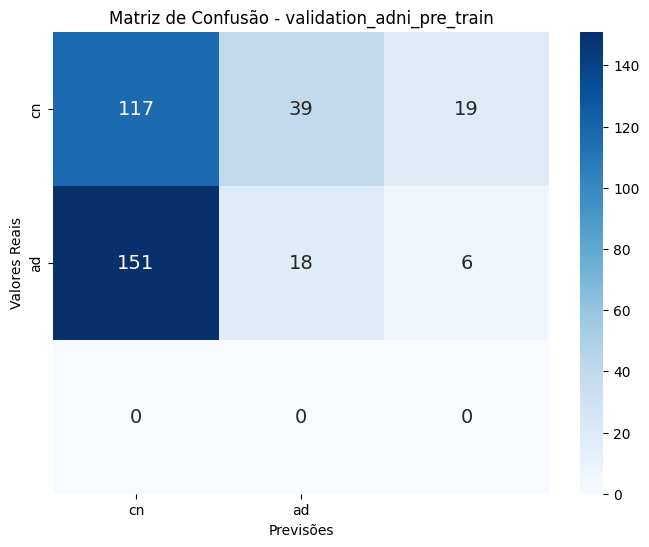

IndexError: list index out of range

In [9]:
# Realizar predições para dados do conjunto validação
val_pred_labels_post_train, val_true_labels_post_train, val_pred_post_train = met_vil.get_predictions(val_images_fine_tunning, val_labels_fine_tunning, 64, base_model)

os.makedirs(f"{results_dir}/pretrained", exist_ok=True)
# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(val_true_labels_post_train, val_pred_labels_post_train, f"{results_dir}/pretrained", 'validation_adni_pre_train')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(val_true_labels_post_train, val_pred_labels_post_train, f"{results_dir}/pretrained", 'validation_adni_pre_train', fine_tunning_class_names)

# Criar pdf com predições
val_pdf_path_post_train = os.path.join(f"{results_dir}/pretrained", "validation_adni_predictions_pre_train.pdf")
met_vil.create_pdf(val_paths_fine_tunning, val_images_fine_tunning, val_true_labels_post_train, val_pred_labels_post_train, val_pred_post_train, val_pdf_path_post_train, fine_tunning_class_names)

### Predição Teste

In [ ]:
test_images_fine_tunning, test_labels_fine_tunning, test_paths_fine_tunning, _ = proc_dados.load_nifti_data_balanced_preallocated(fine_tunning_test_dir, fine_tunning_class_names)

# Realizar predições para dados do conjunto validação
test_pred_labels_fine_tunning, test_true_labels_fine_tunning, test_pred = met_vil.get_predictions(test_images_fine_tunning, test_labels_fine_tunning, 64, base_model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(test_true_labels_fine_tunning, test_pred_labels_fine_tunning, f"{results_dir}/pretrained", 'test_adni_pre_trained')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(test_true_labels_fine_tunning, test_pred_labels_fine_tunning, f"{results_dir}/pretrained", 'test_adni_pre_trained', fine_tunning_class_names)

# Criar pdf com predições
test_pdf_path_fine_tunning = os.path.join(f"{results_dir}/pretrained", "test_adni_predictions_pre_trained.pdf")
met_vil.create_pdf(test_paths_fine_tunning, test_images_fine_tunning, test_true_labels_fine_tunning, test_pred_labels_fine_tunning, test_pred, test_pdf_path_fine_tunning, fine_tunning_class_names)

### Retreinamento

In [ ]:
fase_atual = 2
print("--- INICIANDO FASE 2: FINE-TUNING ---")

# --- CONGELAMENTO E ADAPTAÇÃO ---
# 1. Remover a camada de classificação antiga e adicionar uma nova (ADnetEx)
# Pega a saída da camada anterior à última
x = base_model.layers[-2].output

# Adiciona nova camada de classificação inicializada aleatoriamente
predictions = layers.Dense(n_fine_tunning_class_names, activation='softmax', name='new_output')(x)

model = models.Model(inputs=base_model.input, outputs=predictions)

# 2. Congelar camadas iniciais (Freezing)
# Vamos congelar os dois primeiros blocos convolucionais
for layer in model.layers[1:11]:
    layer.trainable = False
    print(f"Camada congelada: {layer.name}")

# 3. Recompilar
# Usar mesmo learning_rate do pre_treino
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005), 
                loss='categorical_crossentropy', 
                metrics=['categorical_accuracy'])

model.summary()

In [ ]:
batch_size = 32

steps_per_epoch = math.ceil(len(train_images_fine_tunning) / batch_size)
validation_steps = math.ceil(len(val_images_fine_tunning) / batch_size)

train_generator_fine_tunning = proc_dados.nifti_data_generator_3d(train_images_fine_tunning, train_labels_fine_tunning, batch_size)
val_generator_fine_tunning = proc_dados.nifti_data_generator_3d(val_images_fine_tunning, val_labels_fine_tunning, batch_size)

# Callbacks
csv_filename = 'log_treino_fase2.csv'
checkpoint_path = os.path.join(results_dir, "final_model.keras")

callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=25, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1),
    CSVLogger(os.path.join(results_dir, csv_filename)),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_categorical_accuracy', save_best_only=True, mode='max')
]

In [ ]:
epochs = 100 # Fine-tuning geralmente requer menos épocas

print(f"Iniciando treinamento FASE {fase_atual} por {epochs} épocas...")

history_fine_tunning = model.fit(
    train_generator_fine_tunning,
    epochs=epochs,
    verbose=1,
    validation_data=val_generator_fine_tunning,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks_list
)

In [ ]:
# Plotando o histórico de treinamento após o treinamento
os.makedirs(f"{results_dir}/final", exist_ok=True)
met_vil.plot_training_history(history_fine_tunning, f"{results_dir}/final", "fine_tunning_oasis_training_history.png")

### PREDIÇÃO VALIDAÇÃO

In [ ]:
# Realizar predições para dados do conjunto validação
val_pred_labels_post_train, val_true_labels_post_train, val_pred_post_train = met_vil.get_predictions(val_images_fine_tunning, val_labels_fine_tunning, batch_size, model)

os.makedirs(f"{results_dir}/final", exist_ok=True)
# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(val_true_labels_post_train, val_pred_labels_post_train, f"{results_dir}/final", 'validation_adni_post_train')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(val_true_labels_post_train, val_pred_labels_post_train, f"{results_dir}/final", 'validation_adni_post_train', fine_tunning_class_names)

# Criar pdf com predições
val_pdf_path_post_train = os.path.join(f"{results_dir}/final", "validation_adni_predictions_post_train.pdf")
met_vil.create_pdf(val_paths_fine_tunning, val_images_fine_tunning, val_true_labels_post_train, val_pred_labels_post_train, val_pred_post_train, val_pdf_path_post_train, fine_tunning_class_names)

### PREDIÇÃO TESTE

In [ ]:
test_images_fine_tunning, test_labels_fine_tunning, test_paths_fine_tunning, _ = proc_dados.load_nifti_data_balanced_preallocated(fine_tunning_test_dir, fine_tunning_class_names)

# Realizar predições para dados do conjunto validação
test_pred_labels_fine_tunning, test_true_labels_fine_tunning, test_pred = met_vil.get_predictions(test_images_fine_tunning, test_labels_fine_tunning, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(test_true_labels_fine_tunning, test_pred_labels_fine_tunning, f"{results_dir}/final", 'test_adni_fine_tunning')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(test_true_labels_fine_tunning, test_pred_labels_fine_tunning, f"{results_dir}/final", 'test_adni_fine_tunning', fine_tunning_class_names)

# Criar pdf com predições
test_pdf_path_fine_tunning = os.path.join(f"{results_dir}/final", "test_adni_predictions_fine_tunning.pdf")
met_vil.create_pdf(test_paths_fine_tunning, test_images_fine_tunning, test_true_labels_fine_tunning, test_pred_labels_fine_tunning, test_pred, test_pdf_path_fine_tunning, fine_tunning_class_names)